## Compare growth rate and instability with different $f$

### Import package

In [7]:
import numpy as np
import seaborn as sns

from typing import Tuple, Dict, Any
from pathlib import Path

from matplotlib import pyplot as plt

### Load data

In [8]:
# data path
data_path: Path = Path("/home/b11209013/KW_CRI/File")

disp_roots: Dict[str, np.ndarray] = {
    "f=0"   : np.load(data_path / "f_sensitivity/f=0.npy")[99:],
    "f=0.25": np.load(data_path / "f_sensitivity/f=0.25.npy")[99:],
    "f=0.5" : np.load(data_path / "Default.npy")[99:],
    "f=0.75": np.load(data_path / "f_sensitivity/f=0.75.npy")[99:],
    "f=1"   : np.load(data_path / "f_sensitivity/f=1.npy")[99:],
}

### Calculate instability and phase speed

In [9]:
# calculate wavenumber
k_dis: np.ndarray = np.linspace(0, 1e2, 10001)[100:]
k_cal: np.ndarray = 2*np.pi*4320/40000 * k_dis

# calculate linear instability
instab: Dict[str, np.ndarray] = {
    key: -1 * value.imag
    for (key, value) in disp_roots.items()
}

instab_array: np.ndarray = np.array([
    value for value in instab.values()
])

# Calculate phase speed
phase_speed: Dict[str, np.ndarray] = {
    key: (value.real / k_cal[:, None]) * 50
    for (key, value) in disp_roots.items()
}

pspeed_array: np.ndarray = np.array([
    value for value in phase_speed.values()
])


### Visualizing 

#### Fix demonstrating grids

In [10]:
demo_kidx: np.ndarray = np.array([
    np.argmin(np.abs(k_dis - target_k))
    for target_k in [1, 5, 10, 15, 20, 25, 30]
])

#### Visualize linear instability

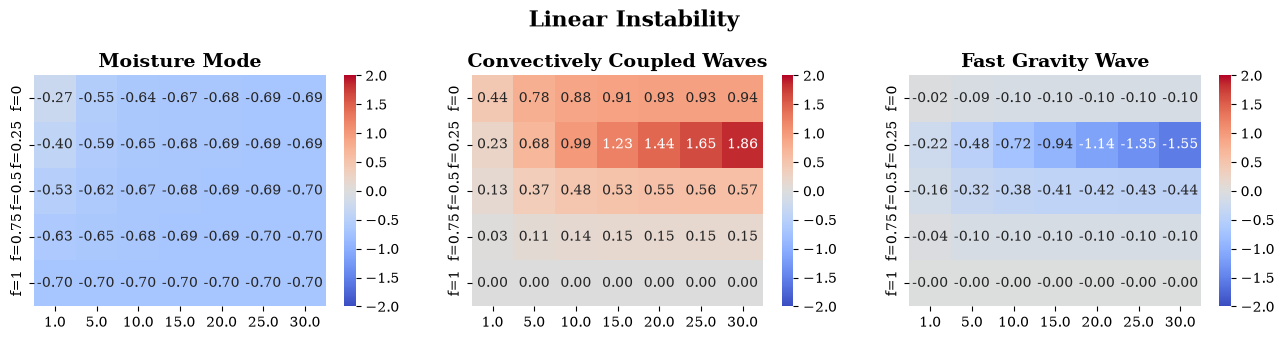

In [11]:
plt.rcParams.update({
    "font.family": "serif"
})

fig, ax = plt.subplots(1, 3, figsize=(16, 3), sharey="col")

sns.heatmap(
    instab_array[..., 0][:, demo_kidx],
    ax=ax[0],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-2.0, vmax=2.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[0].set_title("Moisture Mode", fontsize=14, fontweight="bold")

sns.heatmap(
    instab_array[..., 1][:, demo_kidx],
    ax=ax[1],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-2.0, vmax=2.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[1].set_title("Convectively Coupled Waves", fontsize=14, fontweight="bold")

sns.heatmap(
    instab_array[..., 2][:, demo_kidx],
    ax=ax[2],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-2.0, vmax=2.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[2].set_title("Fast Gravity Wave", fontsize=14, fontweight="bold")

fig.suptitle("Linear Instability", x=0.5, y=1.1, fontsize=16, fontweight="bold")
plt.savefig("/home/b11209013/KW_CRI/Figure/f_sensitivity/instability.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

#### Visualize phase speed

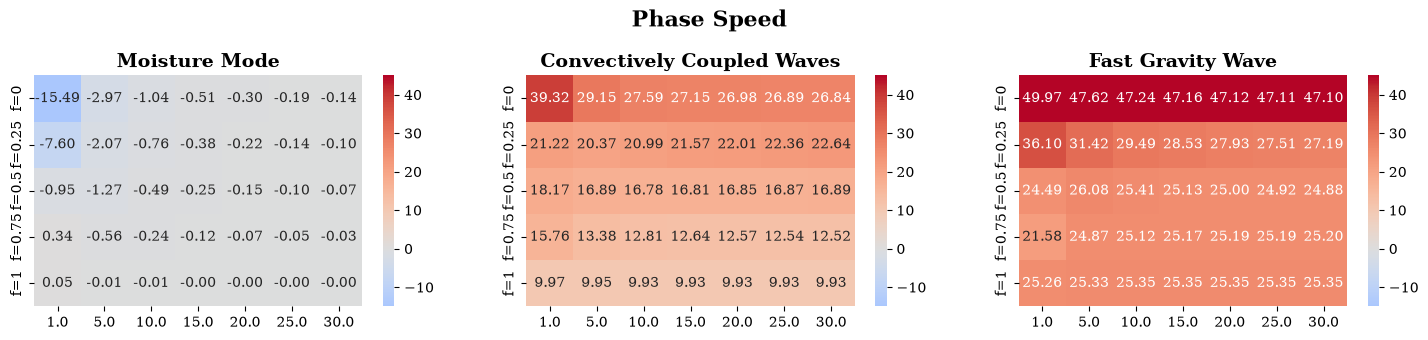

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(18, 3))

sns.heatmap(
    pspeed_array[..., 0][:, demo_kidx],
    ax=ax[0],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-15, vmax=45, center=0.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[0].set_title("Moisture Mode", fontsize=14, fontweight="bold")


sns.heatmap(
    pspeed_array[..., 1][:, demo_kidx],
    ax=ax[1],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-15, vmax=45, center=0.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[1].set_title("Convectively Coupled Waves", fontsize=14, fontweight="bold")


sns.heatmap(
    pspeed_array[..., 2][:, demo_kidx],
    ax=ax[2],
    annot=True,
    fmt=".2f", cmap="coolwarm",
    vmin=-15, vmax=45, center=0.0,
    xticklabels=k_dis[demo_kidx],
    yticklabels=list(instab.keys())
)

ax[2].set_title("Fast Gravity Wave", fontsize=14, fontweight="bold")

fig.suptitle("Phase Speed", x=0.5, y=1.1, fontsize=16, fontweight="bold")
plt.savefig("/home/b11209013/KW_CRI/Figure/f_sensitivity/phase_speed.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)